<a href="https://colab.research.google.com/github/s34836/HTW_DS/blob/main/Exercise_Sheet_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

(150, 5)
   sepal_length  sepal_width  petal_length  petal_width        class
0           5.1          3.5           1.4          0.2  Iris-setosa
1           4.9          3.0           1.4          0.2  Iris-setosa
2           4.7          3.2           1.3          0.2  Iris-setosa
3           4.6          3.1           1.5          0.2  Iris-setosa
4           5.0          3.6           1.4          0.2  Iris-setosa
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   class         150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB
None
       sepal_length  sepal_width  petal_length  petal_width
count    150.000000   150.000000    150.000000   150.000000
mean      

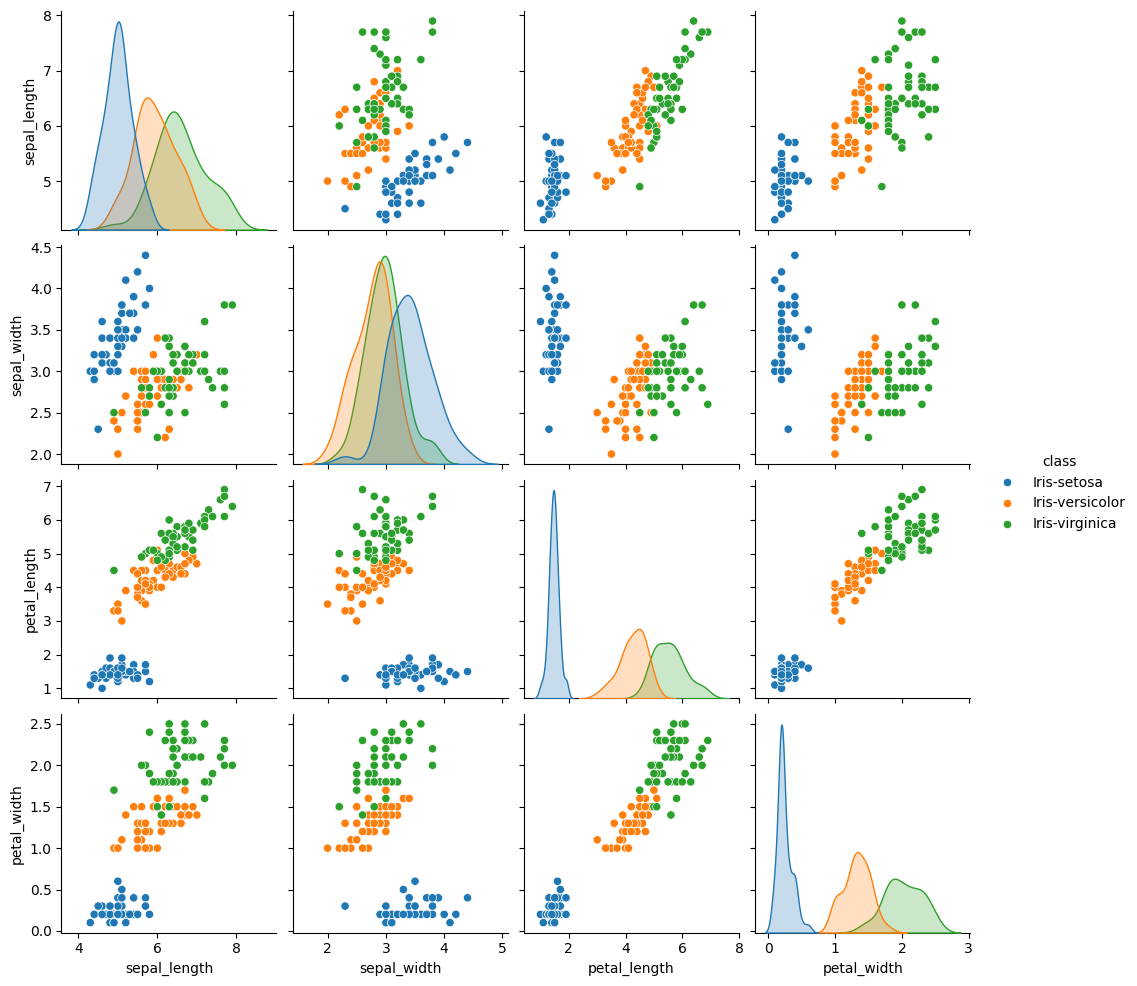

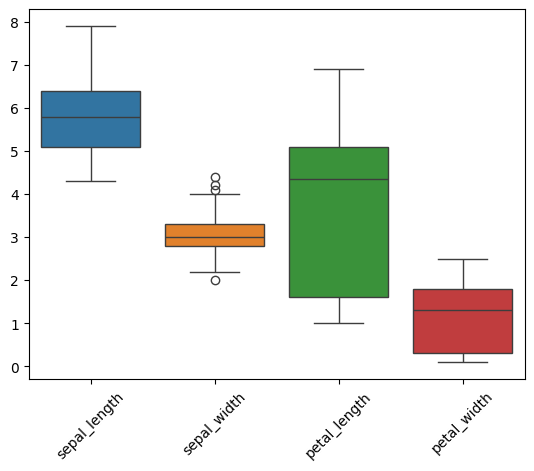

In [6]:
#Exercise 2 Data Analysis - Pre-Processing
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import ssl
import certifi
import urllib.request
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"
columns = [
    "sepal_length", "sepal_width",
    "petal_length", "petal_width", "class"
]
ssl_context = ssl.create_default_context(cafile=certifi.where())
with urllib.request.urlopen(url, context=ssl_context) as response:
    df = pd.read_csv(response, names=columns)
print(df.shape)
print(df.head())
print(df.info())
print(df.describe())
print(df.isna().sum())
sns.pairplot(df, hue="class")
plt.show()
sns.boxplot(data=df.drop(columns="class"))
plt.xticks(rotation=45)
plt.show()


In [7]:
metric_cols = [
  "sepal_length", "sepal_width",
  "petal_length", "petal_width"
]
for col in metric_cols:
  q1 = df[col].quantile(0.25)
  q3 = df[col].quantile(0.75)
  iqr = q3 - q1
  lower = q1 - 1.5 * iqr
  upper = q3 + 1.5 * iqr
  outliers = df[(df[col] < lower) | (df[col] > upper)]
  print(col, len(outliers))

sepal_length 0
sepal_width 4
petal_length 0
petal_width 0


In [8]:
#Exercise 3 File Format Conversion
import pandas as pd
from scipy.io import arff
# Load ARFF file
data, meta = arff.loadarff("weather.arff")
# Convert to pandas DataFrame
df = pd.DataFrame(data)
# Decode byte strings, if necessary
for col in df.select_dtypes([object]).columns:
    df[col] = df[col].str.decode("utf-8")
# Inspect the data
print(df.head())
print(df.info())
print(df.describe(include="all"))
# Save as CSV
df.to_csv("weather.csv", index=False)

    outlook  temperature  humidity  windy play
0     sunny         85.0      85.0  false   no
1     sunny         80.0      90.0   true   no
2  overcast         83.0      86.0  false  yes
3     rainy         70.0      96.0  false  yes
4     rainy         68.0      80.0  false  yes
<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   outlook      10 non-null     str    
 1   temperature  10 non-null     float64
 2   humidity     10 non-null     float64
 3   windy        10 non-null     str    
 4   play         10 non-null     str    
dtypes: float64(2), str(3)
memory usage: 532.0 bytes
None
       outlook  temperature   humidity  windy play
count       10     10.00000  10.000000     10   10
unique       3          NaN        NaN      2    2
top      sunny          NaN        NaN  false   no
freq         4          NaN        NaN      6    5
mean       NaN     73